# Trabalho 06 — Aproximação Funcional com MLP
**EL056 – Redes Neurais Artificiais** · PPGEELT/UFU · Prof. Dr. Keiji Yamanaka  
**Aluno:** Lucas A. Martins (12622EEL006)

> 1) Treinar uma rede neural multicamada (MLP) para aproximar uma função a partir dos pontos amostrados.

Este notebook constrói a MLP passo a passo em NumPy, sem bibliotecas de *deep learning*: propagação direta, retropropagação, verificação numérica do gradiente, treinamento com momento e análise do número de neurônios ocultos. A versão de linha de comando, com todos os experimentos do relatório, está em `trabalho06_mlp.py`.

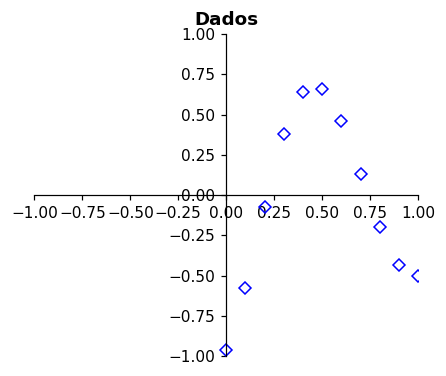

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
t = np.array([-0.9602, -0.5770, -0.0729, 0.3771, 0.6405, 0.6600,
              0.4609, 0.1336, -0.2013, -0.4344, -0.5000])

def eixos_slide(ax):
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    for s in ["left", "bottom"]: ax.spines[s].set_position("zero")
    for s in ["right", "top"]: ax.spines[s].set_color("none")
    ax.set_title("Dados", fontweight="bold")

fig, ax = plt.subplots(figsize=(4.5, 3.8)); eixos_slide(ax)
ax.plot(x, t, "D", mfc="none", mec="blue"); plt.show()

## 1. Arquitetura

Rede **1–N–1**: uma entrada $x$, $N$ neurônios ocultos com tangente hiperbólica e um neurônio de saída **linear**. Para um lote com $P$ padrões, $\mathbf{X}\in\mathbb{R}^{1\times P}$:

$$
\mathbf{net}^{(1)} = \mathbf{W}_1\mathbf{X} + \mathbf{b}_1,\qquad
\mathbf{H} = \tanh\!\left(\mathbf{net}^{(1)}\right),\qquad
\mathbf{Y} = \mathbf{W}_2\mathbf{H} + b_2
$$

A saída é linear porque os alvos saem do intervalo típico de uma sigmoide e porque, pelo Teorema da Aproximação Universal, uma camada oculta sigmoidal seguida de uma combinação linear já basta para aproximar funções contínuas em um intervalo compacto.

In [2]:
def init_weights(N, metodo="nguyen-widrow", rng=None):
    rng = rng or np.random.default_rng(0)
    W1 = rng.uniform(-0.5, 0.5, (N, 1)); b1 = rng.uniform(-0.5, 0.5, (N, 1))
    if metodo == "nguyen-widrow":
        beta = 0.7 * N                      # 0.7 * N^(1/n), com n = 1 entrada
        W1 = beta * W1 / np.abs(W1)         # norma de cada linha = beta
        b1 = rng.uniform(-beta, beta, (N, 1))
    W2 = rng.uniform(-0.5, 0.5, (1, N)); b2 = rng.uniform(-0.5, 0.5, (1, 1))
    return [W1, b1, W2, b2]

def forward(xv, p):
    W1, b1, W2, b2 = p
    X = xv.reshape(1, -1)
    H = np.tanh(W1 @ X + b1)
    Y = W2 @ H + b2
    return Y, (X, H)

p = init_weights(5)
Y, _ = forward(x, p)
print("Saída da rede não treinada:", np.round(Y.ravel(), 3))

Saída da rede não treinada: [-0.982 -0.989 -0.994 -0.997 -1.002 -1.009 -1.02  -1.034 -1.048 -1.06
 -1.068]


## 2. Retropropagação (regra delta generalizada)

Com o erro $E = \frac{1}{2P}\sum_{p}(t_p - y_p)^2$, a regra da cadeia fornece os termos $\delta$:

$$
\boldsymbol{\delta}^{(2)} = \mathbf{Y}-\mathbf{T}\quad(\text{saída linear: } f'=1),\qquad
\boldsymbol{\delta}^{(1)} = \left(\mathbf{W}_2^{\top}\boldsymbol{\delta}^{(2)}\right)\odot\left(1-\mathbf{H}^{2}\right)
$$

$$
\frac{\partial E}{\partial \mathbf{W}_2}=\tfrac1P\boldsymbol{\delta}^{(2)}\mathbf{H}^{\top},\quad
\frac{\partial E}{\partial b_2}=\tfrac1P\textstyle\sum\boldsymbol{\delta}^{(2)},\quad
\frac{\partial E}{\partial \mathbf{W}_1}=\tfrac1P\boldsymbol{\delta}^{(1)}\mathbf{X}^{\top},\quad
\frac{\partial E}{\partial \mathbf{b}_1}=\tfrac1P\textstyle\sum\boldsymbol{\delta}^{(1)}
$$

onde $1-\tanh^2(\cdot)$ é a derivada da tangente hiperbólica.

In [3]:
def backward(tv, Y, cache, p):
    X, H = cache; W2 = p[2]; P = X.shape[1]
    d2 = Y - tv.reshape(1, -1)
    d1 = (W2.T @ d2) * (1 - H**2)
    return [d1 @ X.T / P, d1.sum(1, keepdims=True) / P,
            d2 @ H.T / P, d2.sum(1, keepdims=True) / P]

def erro(p, xv=x, tv=t):
    Y, _ = forward(xv, p)
    return 0.5 * np.mean((tv - Y.ravel())**2)

### 2.1 Verificação numérica do gradiente

Antes de treinar, conferimos se a derivação está correta comparando o gradiente analítico com diferenças finitas centradas, $\frac{E(w+\varepsilon)-E(w-\varepsilon)}{2\varepsilon}$. Um erro relativo da ordem de $10^{-8}$ ou menor confirma a implementação.

In [4]:
p = init_weights(5, rng=np.random.default_rng(1))
Y, cache = forward(x, p)
g_ana = backward(t, Y, cache, p)
eps = 1e-6
for nome, W, G in zip(["W1", "b1", "W2", "b2"], p, g_ana):
    G_num = np.zeros_like(W)
    for i in np.ndindex(W.shape):
        w0 = W[i]
        W[i] = w0 + eps; e1 = erro(p)
        W[i] = w0 - eps; e2 = erro(p)
        W[i] = w0
        G_num[i] = (e1 - e2) / (2 * eps)
    rel = np.linalg.norm(G - G_num) / (np.linalg.norm(G) + np.linalg.norm(G_num))
    print(f"{nome}: erro relativo = {rel:.2e}")

W1: erro relativo = 6.34e-09
b1: erro relativo = 3.91e-10
W2: erro relativo = 8.51e-11
b2: erro relativo = 3.60e-10


## 3. Treinamento: gradiente descendente com momento

$$
\Delta\mathbf{w}(k) = -\alpha\,\nabla E(\mathbf{w}) + \beta\,\Delta\mathbf{w}(k-1),\qquad \mathbf{w}\leftarrow\mathbf{w}+\Delta\mathbf{w}(k)
$$

O treinamento é em lote (uma atualização por época) e para quando o MSE $=\frac1P\sum(t-y)^2$ fica abaixo de $10^{-3}$. Configuração: $N=5$, $\alpha=0{,}05$, $\beta=0{,}9$, inicialização de Nguyen–Widrow e semente 42.

In [5]:
def train(xv, tv, N=5, lr=0.05, mom=0.9, epochs=20000, tol=1e-3, seed=42,
          init="nguyen-widrow", snapshots=()):
    rng = np.random.default_rng(seed)
    p = init_weights(N, init, rng)
    v = [np.zeros_like(w) for w in p]
    hist, snaps = [], {}
    for ep in range(1, epochs + 1):
        Y, cache = forward(xv, p)
        for w, vi, g in zip(p, v, backward(tv, Y, cache, p)):
            vi *= mom; vi -= lr * g; w += vi
        mse = np.mean((tv - forward(xv, p)[0].ravel())**2)
        hist.append(mse)
        if ep in snapshots: snaps[ep] = [w.copy() for w in p]
        if tol and mse < tol: break
    snaps[ep] = [w.copy() for w in p]
    return p, hist, snaps

p, hist, snaps = train(x, t, snapshots=(1, 10, 30, 60))
print(f"Convergiu em {len(hist)} épocas, MSE = {hist[-1]:.4e}")
print(" x     alvo     saída")
for xi, ti, yi in zip(x, t, forward(x, p)[0].ravel()):
    print(f"{xi:.1f}  {ti:+.4f}  {yi:+.4f}")

Convergiu em 89 épocas, MSE = 9.9938e-04
 x     alvo     saída
0.0  -0.9602  -0.9769
0.1  -0.5770  -0.5535
0.2  -0.0729  -0.0577
0.3  +0.3771  +0.3669
0.4  +0.6405  +0.6095
0.5  +0.6600  +0.6379
0.6  +0.4609  +0.4692
0.7  +0.1336  +0.1661
0.8  -0.2013  -0.1603
0.9  -0.4344  -0.4144
1.0  -0.5000  -0.5719


### 3.1 Evolução da aproximação ao longo das épocas

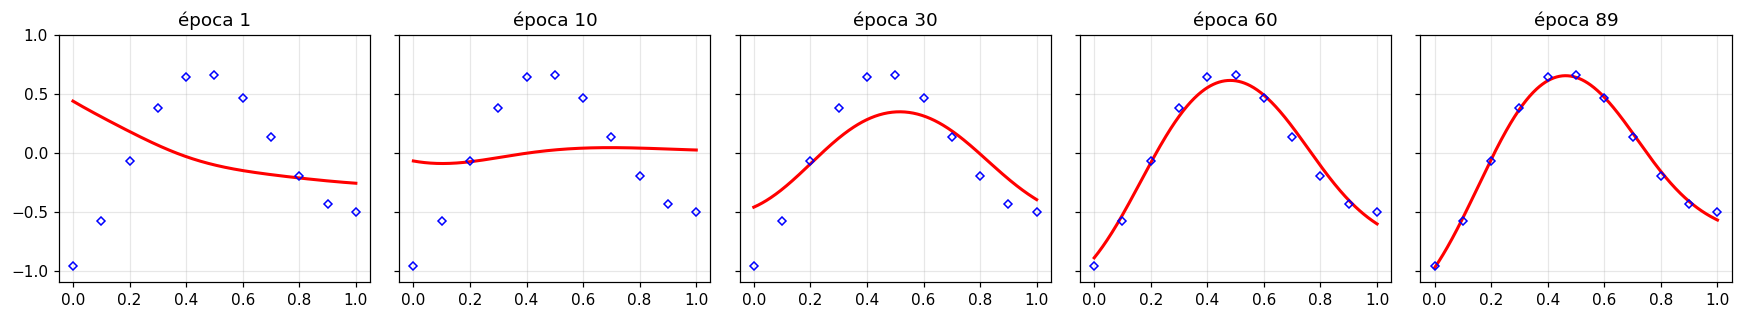

In [6]:
xs = np.linspace(0, 1, 400)
fig, axs = plt.subplots(1, len(snaps), figsize=(3.2 * len(snaps), 3), sharey=True)
for ax, (ep, ps) in zip(axs, snaps.items()):
    ax.plot(xs, forward(xs, ps)[0].ravel(), "r", lw=2)
    ax.plot(x, t, "D", mfc="none", mec="blue", ms=4)
    ax.set_title(f"época {ep}"); ax.set_ylim(-1.1, 1); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3.2 Resultado final (no estilo do slide) e curva de aprendizado

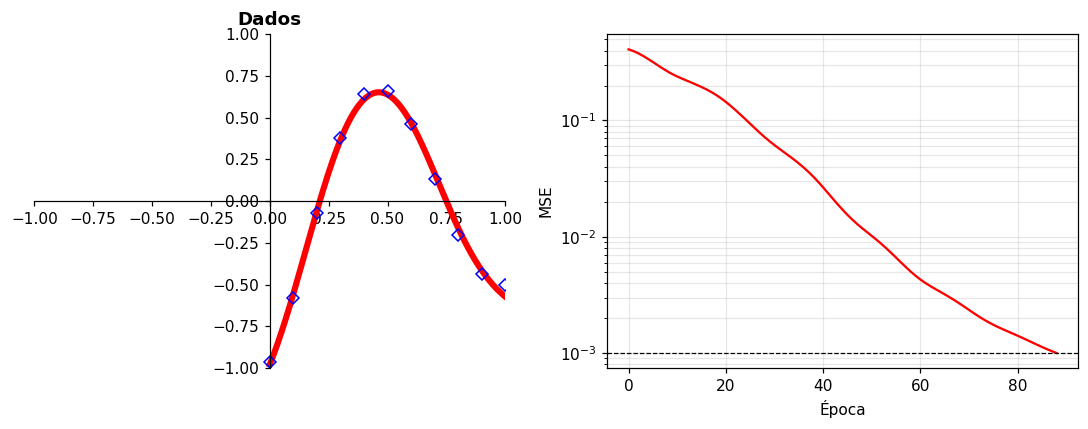

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
eixos_slide(a1)
a1.plot(xs, forward(xs, p)[0].ravel(), "r", lw=4)
a1.plot(x, t, "D", mfc="none", mec="blue")
a2.semilogy(hist, "r"); a2.axhline(1e-3, ls="--", c="k", lw=.8)
a2.set_xlabel("Época"); a2.set_ylabel("MSE"); a2.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()

## 4. Quantos neurônios ocultos?

Com apenas 11 pontos, a escolha de $N$ equilibra **viés** e **variância**. Treinamos cada rede por 50 000 épocas, sem parada antecipada, e estimamos a generalização com *leave-one-out* (LOO): treina-se com 10 pontos e mede-se o erro no ponto retirado, repetindo para os 11 pontos.

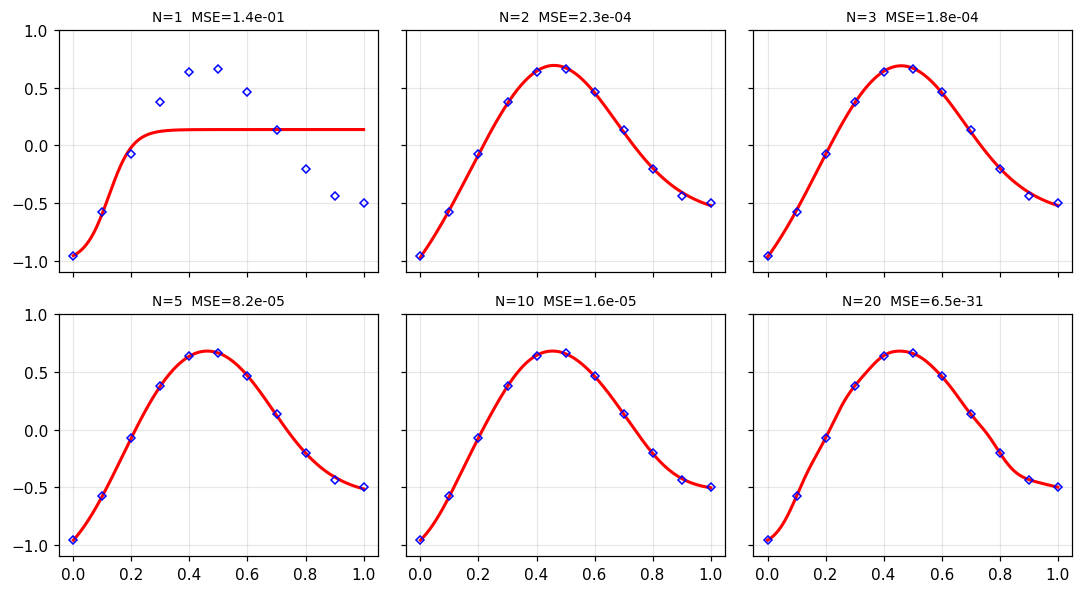

 N   MSE treino   MSE LOO
 1   1.41e-01    3.31e-01
 2   2.27e-04    2.61e-03
 3   1.81e-04    2.86e-03
 5   8.22e-05    8.43e-04
10   1.56e-05    1.31e-03
20   6.55e-31    2.68e-02


In [8]:
Ns = [1, 2, 3, 5, 10, 20]
mse_tr, mse_loo = [], []
fig, axs = plt.subplots(2, 3, figsize=(10, 5.5), sharex=True, sharey=True)
for ax, N in zip(axs.ravel(), Ns):
    pN, hN, _ = train(x, t, N=N, tol=0, epochs=50000)
    mse_tr.append(hN[-1])
    ax.plot(xs, forward(xs, pN)[0].ravel(), "r", lw=2)
    ax.plot(x, t, "D", mfc="none", mec="blue", ms=4)
    ax.set_title(f"N={N}  MSE={hN[-1]:.1e}", fontsize=9); ax.set_ylim(-1.1, 1); ax.grid(alpha=.3)
    errs = []
    for i in range(len(x)):
        m = np.arange(len(x)) != i
        pl, _, _ = train(x[m], t[m], N=N, tol=0, epochs=20000)
        errs.append((forward(x[i:i+1], pl)[0].item() - t[i])**2)
    mse_loo.append(np.mean(errs))
plt.tight_layout(); plt.show()

print(" N   MSE treino   MSE LOO")
for N, a, b in zip(Ns, mse_tr, mse_loo):
    print(f"{N:2d}   {a:.2e}    {b:.2e}")

**Leitura dos resultados.** Com $N=1$ a rede tem viés alto: um único degrau em tanh não reproduz o formato de "sino" (subfitting). A partir de $N=2$ o formato já é capturado. O erro de treino continua caindo com mais neurônios, e com $N=20$ (61 parâmetros para 11 pontos) a rede **interpola** os dados (MSE de treino ≈ 0). O erro LOO, porém, é mínimo perto de $N=5$ e volta a crescer com $N=20$: isso é sobreajuste. Por isso escolhemos $N=5$.

## 5. Extrapolação para $x\in[-1,1]$

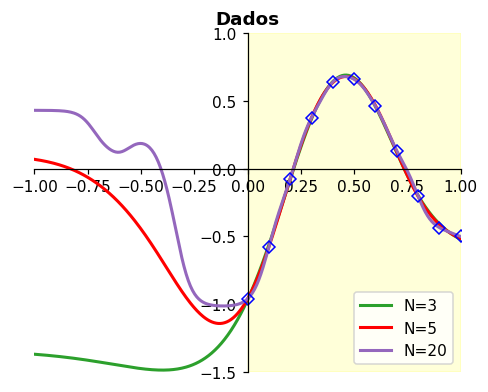

In [9]:
xe = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(5, 4)); eixos_slide(ax); ax.set_ylim(-1.5, 1)
for N, c in [(3, "tab:green"), (5, "red"), (20, "tab:purple")]:
    pN, _, _ = train(x, t, N=N, tol=0, epochs=50000)
    ax.plot(xe, forward(xe, pN)[0].ravel(), c=c, lw=2, label=f"N={N}")
ax.axvspan(0, 1, color="yellow", alpha=.15)
ax.plot(x, t, "D", mfc="none", mec="blue"); ax.legend(loc="lower right"); plt.show()

Dentro de $[0,1]$ (faixa amarela) as três redes praticamente coincidem. Fora dela, cada rede segue um caminho diferente, determinado apenas pela saturação das suas tanh. O Teorema da Aproximação Universal garante a aproximação **no domínio compacto dos dados**, e nada diz sobre o comportamento fora dele.

## 6. Conclusão

Uma MLP 1–5–1 com tanh na camada oculta e saída linear, treinada por *backpropagation* com momento, aproxima os 11 pontos com MSE < $10^{-3}$ em menos de 100 épocas. A curva obtida é suave e passa próxima de todos os pontos, reproduzindo a figura do enunciado. Os experimentos mostram que a capacidade da rede deve ser dimensionada pelo erro de generalização e não pelo erro de treino, que sempre cai com mais neurônios.